In [1]:
from PIL import Image
from PIL.ExifTags import TAGS, GPSTAGS #GPSTAGS, para datos GPS
from pathlib import Path
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#1. Cargar imagenes
#Tipos de imagenes o formatos de imagenes a analizar
extensiones = {'.png', '.jpeg', '.jpg','.jfif'} #Creamos un set (conjunto) 

PATH_DIR = Path("\Portafolio\data\Imagenes\Metadata") #Directorio de imagenes

#2. validad que la ruta existe para evitar errores
if PATH_DIR.exists() and PATH_DIR.is_dir():
    print(f"Explorando archivos en: {PATH_DIR}\n")

    #Iterar sobre los elementos del directorio
    for archivo in PATH_DIR.iterdir():
        #Verificamos que es un archhivo y si su terminación esta en extensiones
        #.suffix devuelve la extensión del archivo en turno, pero en minuscuilas
        if archivo.is_file() and archivo.suffix.lower() in extensiones:
            print(f"Imagen encontrada: {archivo.name}")
else:
    print(f"Ruta especificada no existe o no esta en el directorio")

Explorando archivos en: \Portafolio\data\Imagenes\Metadata

Imagen encontrada: 2019-09-19_meeting-LR-Belfort-assistance.jpg
Imagen encontrada: 2020-03-17_confinement-Belfort-1.jpg
Imagen encontrada: Anfiteatro_de_Pula,_Croacia,_2017-04-16,_DD_01-06_PAN.jpg
Imagen encontrada: Arena_Brøndby_(DEN).jpg
Imagen encontrada: Bus_Ligne_M36_Kurt_Schumacher_Straße_-_Francfort-sur-le-Main_(DE71)_-_2025-11-29_-_2.jpg
Imagen encontrada: Clase_de_Ebussines.jpg
Imagen encontrada: Ewers,_Åbenrå_Havn_2022a.jpg
Imagen encontrada: Filippos_Fragkogiannis_November_2023.png
Imagen encontrada: Fondos_Cabo_de_Gata_06.jpg
Imagen encontrada: Food_at_Wikimania_2019_1.jpg
Imagen encontrada: frame_pol10grados.png
Imagen encontrada: frame_pol20grados.png
Imagen encontrada: frame_pol30grados.png
Imagen encontrada: Gato_comun_atigrado_11.jpg
Imagen encontrada: Gorkhi-Terelj_National_Park_54.jfif
Imagen encontrada: IMG_20241108_131718378_AE.jpg
Imagen encontrada: IMG_20241110_211702530_HDR_AE.jpg
Imagen encontrada: IMG

Los <font color=#FF2400 >**metadatos**</font> de una foto (o datos EXIF/IPTC) son información oculta, incrustada en el archivo que detalla cuándo, dónde y con qué dispositivo se tomó, incluyendo ubicación GPS , modelo de cámara/móvil, ajustes de disparo (ISO, apertura) y fecha. Son fundamentales para organizar archivos y <font color=#FF2400 >**geolocalizar**</font> imágenes.

Esto lo lograremos mediante el uso de la libreria ``PIL`` (o pillow en su antigua versión), la cual es es una potente biblioteca de procesamiento de imágenes que proporciona funcionalidades para abrir, manipular y guardar varios formatos de archivos de imagen. La <font color=#09FF >manipulación</font>
 incluye la **eliminación de metadatos de las imágenes**. 

In [2]:
# 2.5 lista para almacenar la información (futuro dataset)
datos_imagenes = []

# 3. Extraer la información
for archivo in PATH_DIR.iterdir():
    if archivo.is_file() and archivo.suffix.lower() in extensiones:
        try:
            with Image.open(archivo) as img:
                # Metadatos básicos
                info = {
                    "nombre": archivo.name,
                    "extension": archivo.suffix.lower(),
                    "formato": img.format,
                    "ancho": img.size[0],
                    "alto": img.size[1],
                    "modo_color": img.mode
                }
                
                exif_data = img.getexif()
                if exif_data:
                    for tag_id, valor in exif_data.items():
                        tag = TAGS.get(tag_id, tag_id)
                        if tag != "GPSInfo": #Ignoramos el GPS aquí para manejarlo aparte
                            info[f'exif_{tag}'] = str(valor)
                    # El ID 0x8825 (34853) es el estándar para GPSInfo
                    gps_ifd = exif_data.get_ifd(0x8825) 
                    if gps_ifd:
                        for gps_id in gps_ifd:
                            nombre_gps = GPSTAGS.get(gps_id, gps_id)
                            info[f"gps_{nombre_gps}"] = gps_ifd[gps_id]
                        

                datos_imagenes.append(info)
        except Exception as e:
            print(f"No se pudo procesar archivo {archivo.name}: {e}")

# 4. Crear el dataframe
df_metadata = pd.DataFrame(datos_imagenes)

# Limpieza del DataFrame

In [3]:
#1. Vemos cuantos valores nulos hay por columna
print("Valores nulos por columna:")
print(df_metadata.isnull().sum())

#2. Eliminamos columnas que esten completamente vacias
#Aveces el extractor creara columas Exif que nadie tiene
df_metadata.dropna(axis=1,how='all',inplace=True)

#3. Rellenar valores NaN en columnas de texto (String)
#En lugar de NaN, es mejor poner 'N/A' o 'Desconocido para reportes posteriores
df_metadata.fillna({'exif_model':'Desconocido','exif_DateTime': 'Sin Fecha'}, inplace=True)


#4. Rellenar valores numericos con la mediana o 0
#Por ejemplo, si alguna imagen no reportó tamaño
df_metadata['ancho'] = df_metadata['ancho'].fillna(0)

Valores nulos por columna:
nombre                            0
extension                         0
formato                           0
ancho                             0
alto                              0
modo_color                        0
exif_ResolutionUnit               7
exif_ExifOffset                   7
exif_ImageDescription            17
exif_YResolution                  7
exif_DateTime                     9
exif_YCbCrPositioning             8
exif_Copyright                   32
exif_XResolution                  7
exif_Artist                      33
gps_GPSVersionID                 16
gps_GPSLatitudeRef               17
gps_GPSLatitude                  17
gps_GPSLongitudeRef              17
gps_GPSLongitude                 17
gps_GPSAltitudeRef               18
gps_GPSAltitude                  18
gps_GPSTimeStamp                 19
gps_GPSMapDatum                  34
gps_GPSDateStamp                 19
gps_GPSImgDirectionRef           33
gps_GPSImgDirection              33
e

# Optimización de tipos de datos

In [4]:
#Convertimos columnas a tipos más eficientes para volumenes grandes de información
df_metadata['extension'] = df_metadata['extension'].astype('category')
df_metadata['formato'] = df_metadata['formato'].astype('category')
df_metadata['modo_color'] = df_metadata['modo_color'].astype('category')

# Creación de columnas derivadas para facilidad en el analisis posterior

In [5]:
# Calcular megapixeles (util para analisis de calidad)
df_metadata['megapixeles'] = (df_metadata['ancho'] * df_metadata['alto'])/1000000

#Clasificador por orientación
df_metadata['orientacion'] = np.where(df_metadata['ancho']>df_metadata['alto'], 'Horizontal','Vertical')

Dependiendo del tipo de dato rellenaremos los valores NaN con su tipo de valor correcto (0 o Desconocido)

In [6]:
'''Rellenar las columnas numéricas con 0 o mediana (escogeremos la mediana de la
misma columna para fines estadisticos). pero la versión con 0 tambien estara disponible'''
columnas_numericas = df_metadata.select_dtypes(include=['number']).columns
#df_metadata[columnas_numericas] = df_metadata[columnas_numericas].fillna(0)

'''for col in columnas_numericas:
    #calculamos la mediana de la columna en turno
    mediana = df_metadata[col].median()
    #Rellenamos solo esa columna
    df_metadata[col] = df_metadata[col].fillna(mediana)'''

#Forma optimizada
df_metadata.fillna(df_metadata.median(numeric_only=True),inplace=True)

#Rellenamos todas las columnas de texto (llamadas object) con "Sin Datos"
columnas_texto = df_metadata.select_dtypes(include=['string']).columns
df_metadata[columnas_texto] = df_metadata[columnas_texto].fillna("Sin Datos")

In [7]:
df_metadata.head()

,nombre,extension,formato,ancho,alto,modo_color,exif_ResolutionUnit,exif_ExifOffset,exif_ImageDescription,exif_YResolution,...,exif_RelatedImageWidth,exif_RelatedImageLength,exif_Rating,exif_RatingPercent,exif_SensitivityType,exif_CameraOwnerName,exif_XPTitle,exif_XPSubject,megapixeles,orientacion
0,2019-09-19_meeting-LR-Belfort-assistance.jpg,.jpg,JPEG,1920,1080,RGB,1,588,"Réunion militante du parti ""Les Républicains"",...",1.0,...,Sin Datos,Sin Datos,Sin Datos,Sin Datos,Sin Datos,Sin Datos,Sin Datos,Sin Datos,2.073600,Horizontal
1,2020-03-17_confinement-Belfort-1.jpg,.jpg,JPEG,3840,2160,RGB,1,Sin Datos,"Les conséquences de la quarantaine, à Belfort,...",1.0,...,Sin Datos,Sin Datos,Sin Datos,Sin Datos,Sin Datos,Sin Datos,Sin Datos,Sin Datos,8.294400,Horizontal
2,"Anfiteatro_de_Pula,_Croacia,_2017-04-16,_DD_01...",.jpg,JPEG,960,280,RGB,Sin Datos,Sin Datos,Sin Datos,Sin Datos,...,Sin Datos,Sin Datos,Sin Datos,Sin Datos,Sin Datos,Sin Datos,Sin Datos,Sin Datos,0.268800,Horizontal
3,Arena_Brøndby_(DEN).jpg,.jpg,JPEG,2007,1326,RGB,2,240,Sin Datos,72.0,...,Sin Datos,Sin Datos,Sin Datos,Sin Datos,Sin Datos,Sin Datos,Sin Datos,Sin Datos,2.661282,Horizontal
4,Bus_Ligne_M36_Kurt_Schumacher_Straße_-_Francfo...,.jpg,JPEG,4032,3024,RGB,2,228,Sin Datos,72.0,...,Sin Datos,Sin Datos,Sin Datos,Sin Datos,Sin Datos,Sin Datos,Sin Datos,Sin Datos,12.192768,Horizontal


Notamos que aunque las columnas como fecha y modelo existen en el dtaframe, al mostrarlas directamente no se presentan o se dejan ver de manera facil al primer intento por lo cual debemos de crear un "dataframe con solo cosas de alto valor"

Además de que nos encargaremos de mejor limpiar ciertos valores de la columna de fabricante

In [8]:
# Buscamos dinámicamente cualquier columna que empiece con 'gps_'
columnas_gps = [col for col in df_metadata.columns if col.startswith('gps_')]

# Unimos nuestras columnas básicas con las de GPS
columnas_interes = [
    'nombre', 'extension', 'formato', 'ancho', 'alto', 
    'exif_DateTime', 'exif_Make', 'exif_Model', 'megapixeles', 'orientacion'
] + columnas_gps

df_limpio = df_metadata[columnas_interes].copy()

# Renombrado (igual que antes)
df_limpio.rename(columns={
    'exif_DateTime': 'fecha_captura',
    'exif_Make': 'fabricante',
    'exif_Model': 'modelo'
}, inplace=True)

In [9]:
# Convertir el texto a formato fecha de verdad
df_limpio['fecha_captura'] = pd.to_datetime(
    df_limpio['fecha_captura'], 
    format='%Y:%m:%d %H:%M:%S', 
    errors='coerce' # Si la fecha está rota, pone NaT (Not a Time)
)
df_limpio.loc[df_limpio['fabricante'].str.contains('motorola', case=False, na=False), 'fabricante'] = 'Motorola'
df_limpio.head()

,nombre,extension,formato,ancho,alto,fecha_captura,fabricante,modelo,megapixeles,orientacion,...,gps_GPSMapDatum,gps_GPSDateStamp,gps_GPSImgDirectionRef,gps_GPSImgDirection,gps_GPSSpeedRef,gps_GPSSpeed,gps_GPSDestBearingRef,gps_GPSDestBearing,gps_GPSHPositioningError,gps_GPSProcessingMethod
0,2019-09-19_meeting-LR-Belfort-assistance.jpg,.jpg,JPEG,1920,1080,2019-09-19 20:00:41,Sin Datos,Sin Datos,2.073600,Horizontal,...,WGS-84,2019:09:19,Sin Datos,NaN,Sin Datos,NaN,Sin Datos,NaN,NaN,NaN
1,2020-03-17_confinement-Belfort-1.jpg,.jpg,JPEG,3840,2160,NaT,Sin Datos,Sin Datos,8.294400,Horizontal,...,WGS-84,2020:03:17,M,0.0,Sin Datos,NaN,Sin Datos,NaN,NaN,NaN
2,"Anfiteatro_de_Pula,_Croacia,_2017-04-16,_DD_01...",.jpg,JPEG,960,280,NaT,Sin Datos,Sin Datos,0.268800,Horizontal,...,Sin Datos,Sin Datos,Sin Datos,NaN,Sin Datos,NaN,Sin Datos,NaN,NaN,NaN
3,Arena_Brøndby_(DEN).jpg,.jpg,JPEG,2007,1326,2014-01-03 11:20:48,FUJIFILM,FinePix S5000,2.661282,Horizontal,...,Sin Datos,Sin Datos,Sin Datos,NaN,Sin Datos,NaN,Sin Datos,NaN,NaN,NaN
4,Bus_Ligne_M36_Kurt_Schumacher_Straße_-_Francfo...,.jpg,JPEG,4032,3024,2025-11-29 11:46:34,Apple,iPhone 16 Pro,12.192768,Horizontal,...,Sin Datos,2025:11:29,T,164.8561476837339,K,2.9102582917522746,T,164.8561476837339,41.64922118380062,NaN


no podremos graficar una tupla como (19.0, 24.0, 30.5). Necesitas un solo número. Esta función hace la magia matemática: 

$Grados + \frac{Minutos}{60} + \frac{Segundos}{3600}$.

In [10]:
def convertir_a_decimal(coord_tuple, ref):
    if not isinstance(coord_tuple, (tuple, list)) or pd.isna(ref):
        return None
    
    # Extraemos grados, minutos y segundos asegurando que sean float
    d = float(coord_tuple[0])
    m = float(coord_tuple[1]) / 60
    s = float(coord_tuple[2]) / 3600
    
    decimal = d + m + s
    
    # Si es Sur o Oeste, el valor debe ser negativo
    if ref in ['S', 'W']:
        decimal = -decimal
        
    return decimal

Ahora aplicamos la función a las columnas correspondientes para crear nuestras columnas finales de latitud y longitud.

In [11]:
# Creamos la Latitud
if 'gps_GPSLatitude' in df_limpio.columns:
    df_limpio['latitud'] = df_limpio.apply(
        lambda x: convertir_a_decimal(x.get('gps_GPSLatitude'), x.get('gps_GPSLatitudeRef')), 
        axis=1
    )

# Creamos la Longitud
if 'gps_GPSLongitude' in df_limpio.columns:
    df_limpio['longitud'] = df_limpio.apply(
        lambda x: convertir_a_decimal(x.get('gps_GPSLongitude'), x.get('gps_GPSLongitudeRef')), 
        axis=1
    )

# Ahora podemos eliminar las columnas de GPS originales que son difíciles de leer
cols_a_eliminar = [c for c in df_limpio.columns if c.startswith('gps_')]
df_limpio.drop(columns=cols_a_eliminar, inplace=True)

In [12]:
df_final = df_limpio.copy()
#Cantidad de muestras a analizar
print(f'Número de muestras: {len(df_final)}')

Número de muestras: 36


In [19]:

# 6. Eliminar las columnas de GPS originales que son difíciles de leer
cols_a_eliminar = [c for c in df_final.columns if c.startswith('gps_')]
df_final.drop(columns=cols_a_eliminar, inplace=True)

# Visualización inicial del DataFrame final
print("\nPrimeras filas del DataFrame limpio con GPS decimal:")
print(df_final.head())


Primeras filas del DataFrame limpio con GPS decimal:
                                              nombre extension formato  ancho  \
0       2019-09-19_meeting-LR-Belfort-assistance.jpg      .jpg    JPEG   1920   
1               2020-03-17_confinement-Belfort-1.jpg      .jpg    JPEG   3840   
2  Anfiteatro_de_Pula,_Croacia,_2017-04-16,_DD_01...      .jpg    JPEG    960   
3                            Arena_Brøndby_(DEN).jpg      .jpg    JPEG   2007   
4  Bus_Ligne_M36_Kurt_Schumacher_Straße_-_Francfo...      .jpg    JPEG   4032   

   alto       fecha_captura fabricante          modelo  megapixeles  \
0  1080 2019-09-19 20:00:41  Sin Datos       Sin Datos     2.073600   
1  2160                 NaT  Sin Datos       Sin Datos     8.294400   
2   280                 NaT  Sin Datos       Sin Datos     0.268800   
3  1326 2014-01-03 11:20:48   FUJIFILM  FinePix S5000      2.661282   
4  3024 2025-11-29 11:46:34      Apple   iPhone 16 Pro    12.192768   

  orientacion    latitud  longit

In [20]:
# Resumen estadístico de las coordenadas
print("\nResumen estadístico de latitud y longitud:")
print(df_final[['latitud', 'longitud']].describe())


Resumen estadístico de latitud y longitud:
         latitud   longitud
count  19.000000  19.000000
mean   24.048209 -66.960168
std    19.368340  51.902260
min   -34.658539 -99.246735
25%    19.293018 -99.246670
50%    19.293171 -99.182709
75%    29.765191 -25.904583
max    55.040448  44.531769


# Analisis del DataFrame

Con el dataframe listo y refinado, podemos empezar a trabajar en el analisis de dicho dataframe para comenzar a resolver dudas

- Cuantas muestras tenemos para este analisis
- cual es el promedio de resolución de las fotografias
- cual es el formato promedio de las fotos
- 

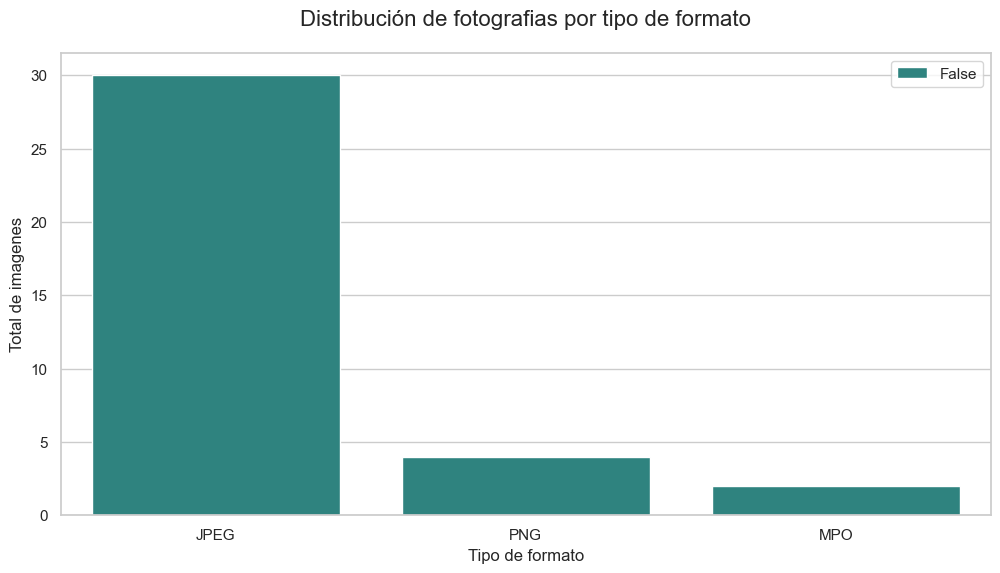

formato
JPEG    30
PNG      4
MPO      2
Name: count, dtype: int64

In [13]:
sns.set_theme(style='whitegrid')
plt.figure(figsize=(12,6))

#ordenamos de mayor a menor frecuencia atuomaticamente
#palette: 'viridis,'magma' o ' rocket'
sns.countplot(
    data= df_limpio,
    x = 'formato',
    order = df_limpio['formato'].value_counts().index,
    palette = 'viridis',hue = False
)

plt.title('Distribución de fotografias por tipo de formato',fontsize = 16,pad=20)
plt.xlabel('Tipo de formato')
plt.ylabel('Total de imagenes')
plt.show()
df_final['formato'].value_counts()

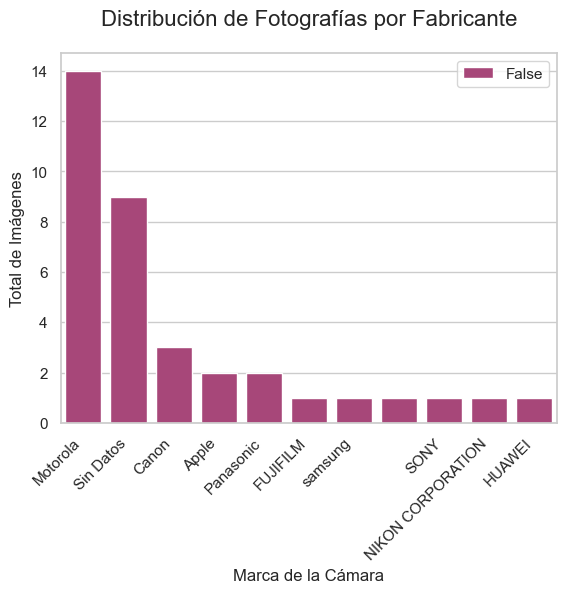

In [14]:
grafico = sns.countplot(
    data = df_final,
    x = 'fabricante',
    order=df_final['fabricante'].value_counts().index,
    palette = 'magma',hue=False
)

plt.title('Distribución de Fotografías por Fabricante', fontsize=16, pad=20)
plt.xlabel('Marca de la Cámara', fontsize=12)
plt.ylabel('Total de Imágenes', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotación inclinada para mejor lectura

plt.show()

Resolución promedio de las fotos analizadas 12.99 Mega Pixeles


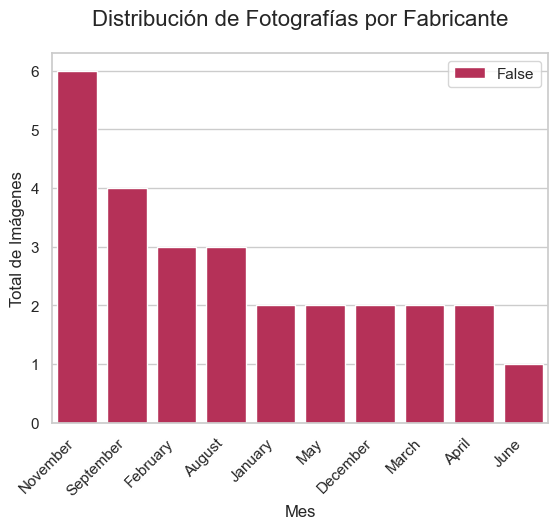

In [15]:
#Resolución promedio de las fotos
Res_mean = df_final['megapixeles'].mean()
print(f'Resolución promedio de las fotos analizadas {Res_mean:.2f} Mega Pixeles')

#Creamos una columna para los meses y ver qué podemos hacer
df_final['Mes'] = df_final['fecha_captura'].dt.month_name()

sns.countplot(
    data=df_final,
    x = 'Mes',
    order=df_final['Mes'].value_counts().index,
    palette='rocket',hue = False
)

plt.title('Distribución de Fotografías por Fabricante', fontsize=16, pad=20)
#plt.xlabel('Mes', fontsize=12)
plt.ylabel('Total de Imágenes', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotación inclinada para mejor lectura

plt.show()